In [1]:
import tensorflow as tf
import os
print(tf.config.list_physical_devices('GPU'))

2025-10-05 12:28:58.208853: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-05 12:28:58.317978: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-05 12:29:01.790367: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
image_dir_path = './openEDS/openEDS/train/images'
label_dir_path = './openEDS/openEDS/train/labels'

from vitsModel.DataLoader import DataLoader

images, labels = DataLoader.load_grayscale_images_label_pairs(
    image_dir_path, label_dir_path,
    step=0, step_size=2500,
    target_size=(224, 224),
    add_noise=False,
    normalize_on_load=False  # Will be normalized in training pipeline
)

Total images found: 27431
Total labels found: 27431
📊 Loading batch 1: indices 0 to 2499


In [6]:
base_drop_rate = 0.3
sensitivity_strength = 0.5
anonymization_strength = 0.5
differential_privacy_noise = 0.1

# Clear and fresh import
from vitsModel.PrivacyVitsModel import PrivacyVitsModel
from vitsModel.Pipeline import Pipeline

# Create instance
privacy_model = PrivacyVitsModel()

# Call the method
model, callbacks = privacy_model.create_and_compile_model_with_privacy(
    base_drop_rate=0.1,
    sensitivity_strength=0.5,
    dp_clip_norm=0,
    anonymization_strength=0,
    differential_privacy_noise=0
)

# 2. Your data paths

    
# Train with enhanced pipeline
model, history, eval_results = Pipeline.complete_training_pipeline(
model, callbacks, images, labels,
epochs=15,
batch_size=4,
test_size=0.2,
enhanced_augmentation=True,
verbose_evaluation=True
)

TypeError: Pipeline.complete_training_pipeline() got multiple values for argument 'epochs'

2025-10-05 09:42:48.103699: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_49', 40 bytes spill stores, 44 bytes spill loads

2025-10-05 09:42:49.660532: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 48 bytes spill stores, 48 bytes spill loads

2025-10-05 09:42:49.857573: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 48 bytes spill stores, 48 bytes spill loads

2025-10-05 09:42:50.079391: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 68 bytes spill stores, 68 bytes spill loads

2025-10-05 09:42:51.147042: I external/local_xla/xl

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


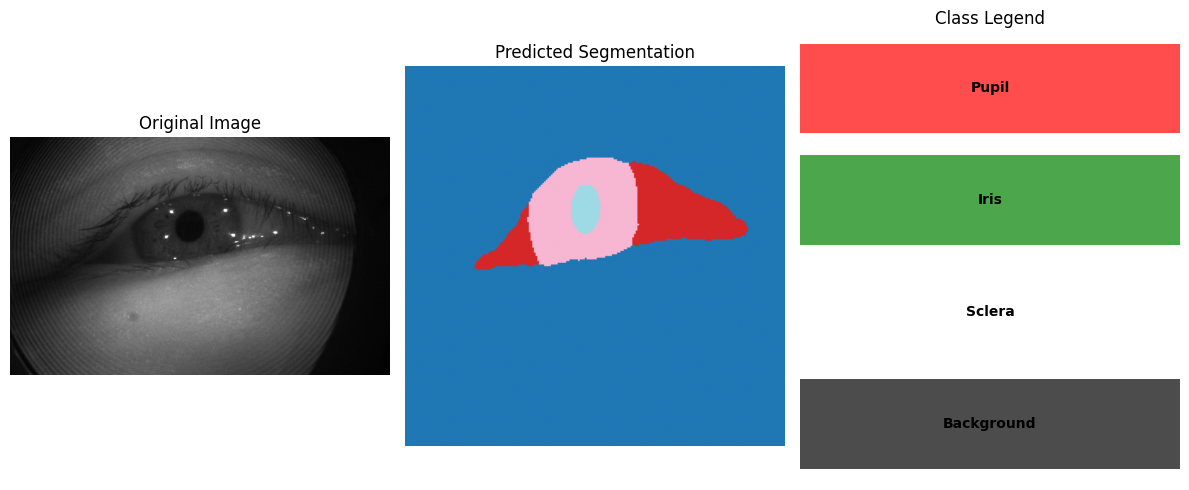

🎯 Starting Complete Model Visualization Pipeline
Extracting features from all layers...
✓ patch_extract_2: (1, 196, 256)
✓ patch_embedding_2: (1, 197, 768)


✓ adaptive_privacy_patch_drop_2: (1, 197, 768)


2025-10-05 09:43:00.354492: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_10', 4 bytes spill stores, 4 bytes spill loads

2025-10-05 09:43:01.464116: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 8 bytes spill stores, 8 bytes spill loads

2025-10-05 09:43:01.554430: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 8 bytes spill stores, 8 bytes spill loads

2025-10-05 09:43:01.604908: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_10', 4 bytes spill stores, 4 bytes spill loads

2025-10-05 09:43:01.912064: I external/local_xla/xla/strea

✓ transformer_block_16: (1, 197, 768)
✓ transformer_block_17: (1, 197, 768)
✓ transformer_block_18: (1, 197, 768)
✓ transformer_block_19: (1, 197, 768)
✓ transformer_block_20: (1, 197, 768)
✓ transformer_block_21: (1, 197, 768)
✓ transformer_block_22: (1, 197, 768)
✓ transformer_block_23: (1, 197, 768)
✓ layer_normalization_50: (1, 197, 768)
✓ differential_privacy_layer_2: (1, 197, 768)
✓ get_item_2: (1, 196, 768)
✓ reshape_2: (1, 14, 14, 768)
✓ upsample_block_8: (1, 28, 28, 512)
✓ upsample_block_9: (1, 56, 56, 256)
✓ upsample_block_10: (1, 112, 112, 128)
✓ upsample_block_11: (1, 224, 224, 64)
✓ segmentation: (1, 224, 224, 4)

📸 Visualizing Patch Extraction...


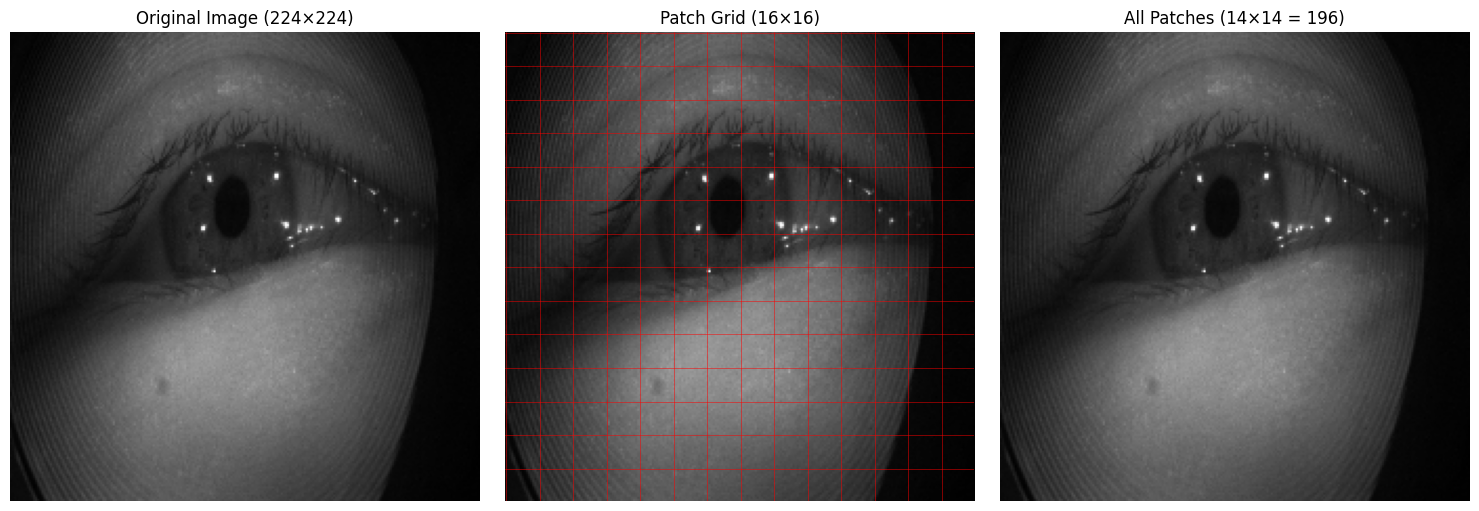


🔍 Visualizing Attention Patterns...


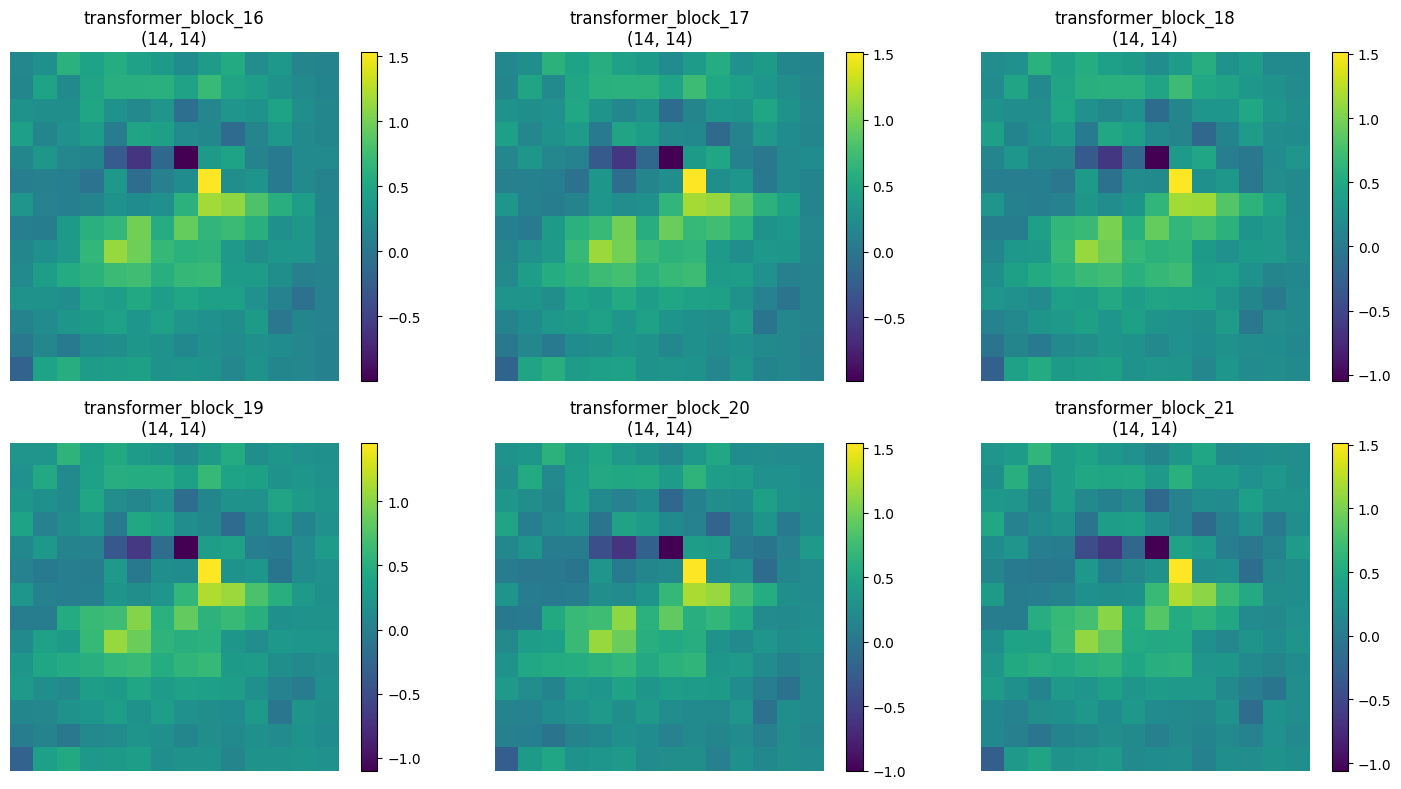


🔒 Visualizing Privacy Layers...


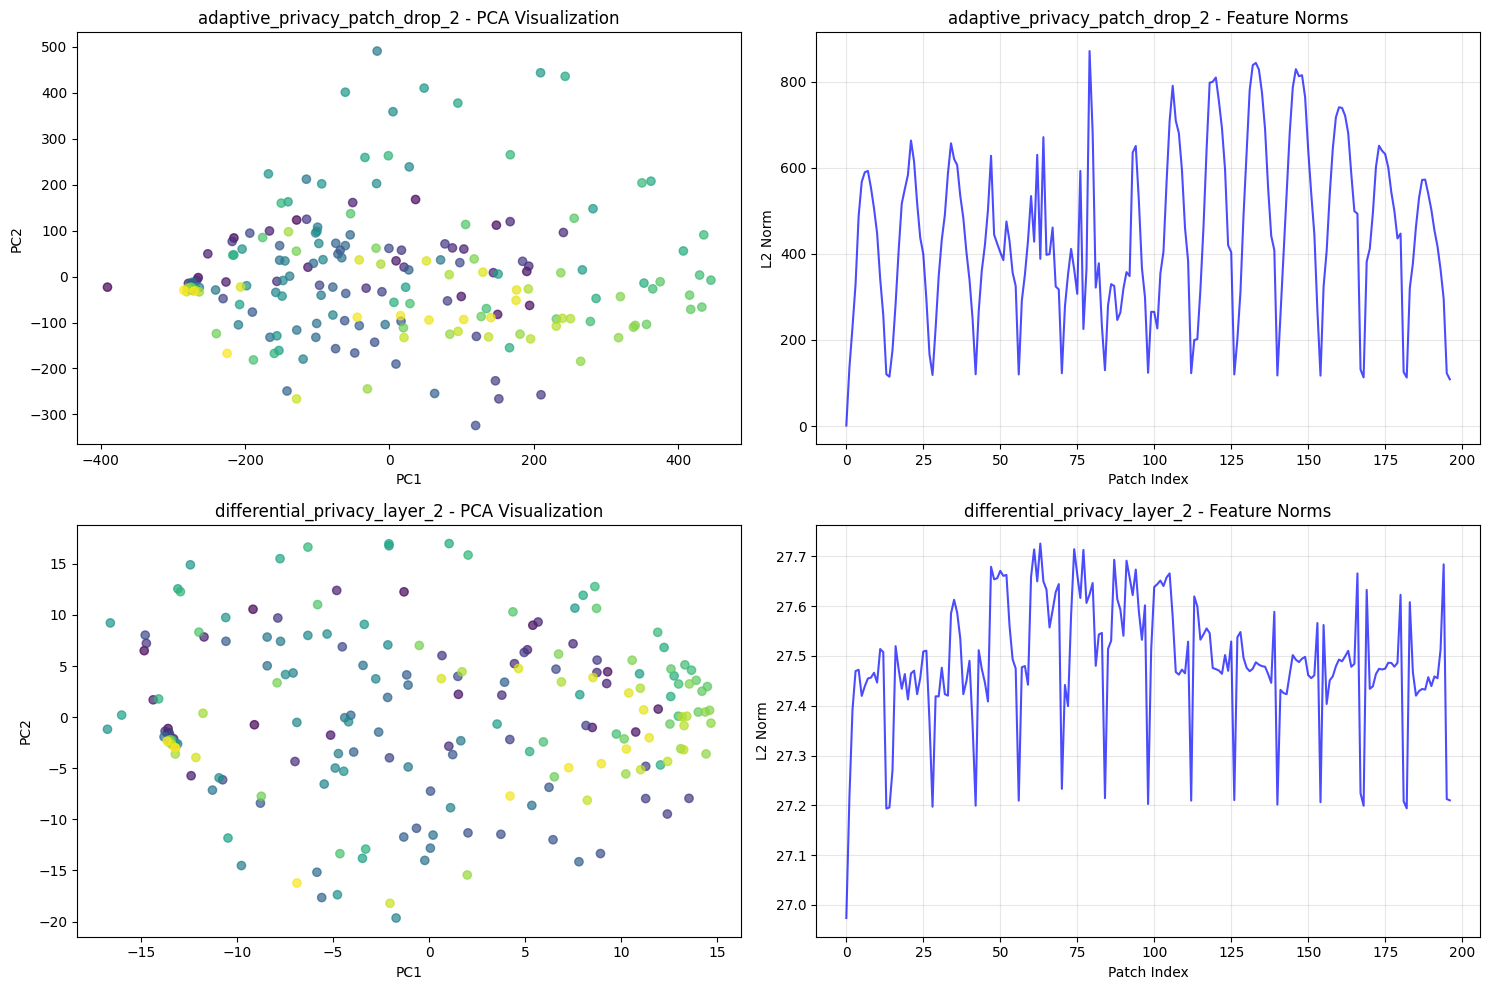


🔄 Visualizing Decoder Progression...


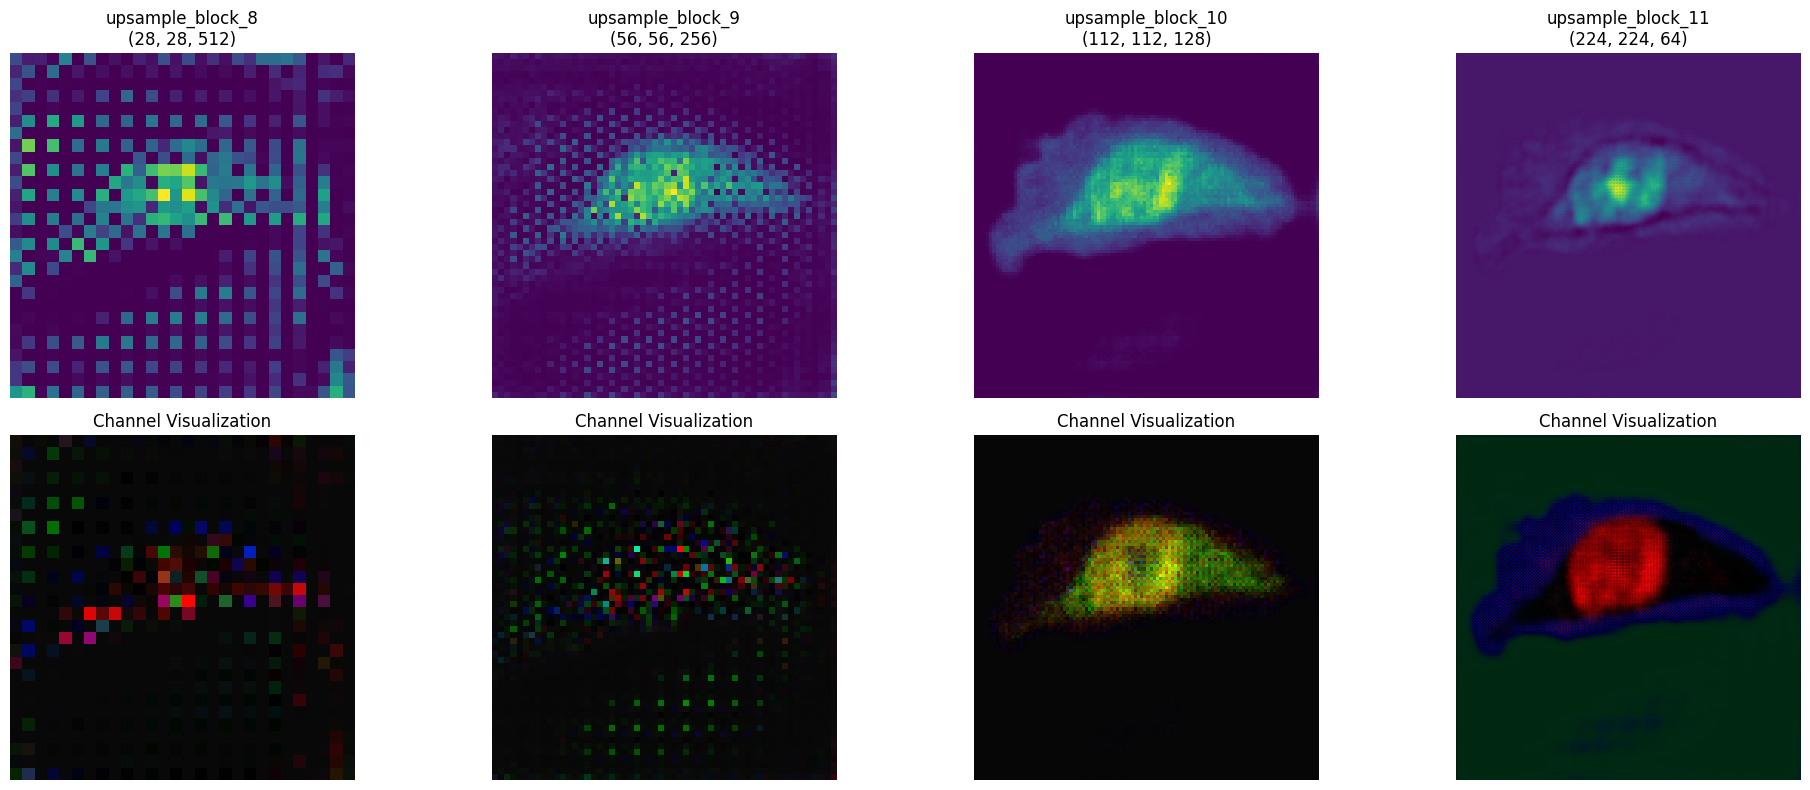


📊 Visualizing Feature Statistics...


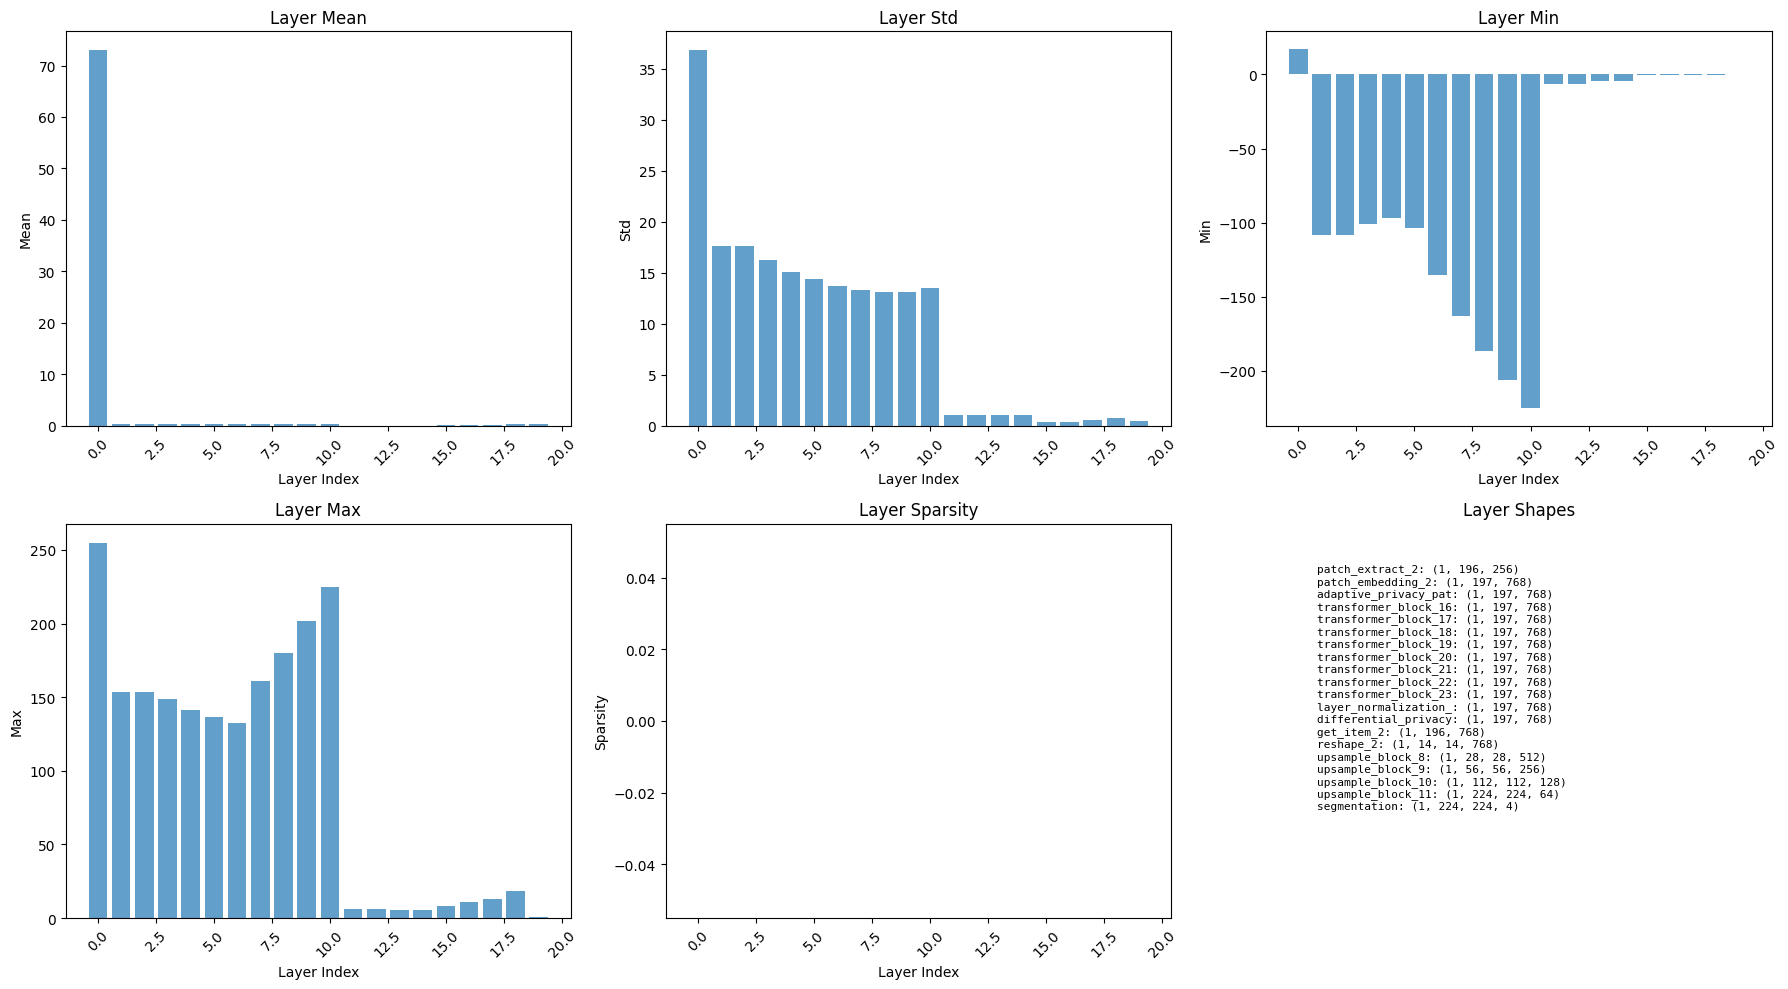


✅ Complete visualization finished!
Prediction completed! Mask shape: (224, 224)
Unique classes in prediction: [0 1 2 3]


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.patches import Rectangle
import seaborn as sns
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

class LayerVisualizationTool:
    """
    Comprehensive tool to visualize outputs from each layer of the ViT eye segmentation model
    """
    
    def __init__(self, model):
        self.model = model
        self.layer_outputs = {}
        self.feature_extractors = self._build_feature_extractors()
        
    def _build_feature_extractors(self):
        """Build feature extractors for each interesting layer"""
        extractors = {}
        
        # Get all layers
        for i, layer in enumerate(self.model.layers):
            layer_name = layer.name
            
            # Skip input layer and some intermediate layers that might cause issues
            if 'input' in layer_name.lower():
                continue
                
            try:
                # Create feature extractor for this layer
                extractor = tf.keras.Model(
                    inputs=self.model.input,
                    outputs=layer.output,
                    name=f"extractor_{layer_name}"
                )
                extractors[layer_name] = {
                    'extractor': extractor,
                    'layer_type': type(layer).__name__,
                    'layer_index': i
                }
            except Exception as e:
                print(f"Skipping layer {layer_name}: {str(e)}")
                
        return extractors
    
    def extract_all_features(self, image):
        """Extract features from all layers"""
        print("Extracting features from all layers...")
        
        for layer_name, layer_info in self.feature_extractors.items():
            try:
                features = layer_info['extractor'].predict(image, verbose=0)
                self.layer_outputs[layer_name] = {
                    'features': features,
                    'layer_type': layer_info['layer_type'],
                    'layer_index': layer_info['layer_index'],
                    'shape': features.shape
                }
                print(f"✓ {layer_name}: {features.shape}")
            except Exception as e:
                print(f"✗ Failed to extract from {layer_name}: {str(e)}")
    
    def visualize_patch_extraction(self, image, patch_size=16):
        """Visualize how the image is divided into patches"""
        plt.figure(figsize=(15, 5))
        
        # Original image
        plt.subplot(1, 3, 1)
        img_display = image[0].squeeze()
        plt.imshow(img_display, cmap='gray')
        plt.title('Original Image (224×224)')
        plt.axis('off')
        
        # Image with patch grid overlay
        plt.subplot(1, 3, 2)
        plt.imshow(img_display, cmap='gray')
        
        # Draw patch grid
        h, w = img_display.shape
        for i in range(0, h, patch_size):
            plt.axhline(y=i, color='red', linewidth=0.5, alpha=0.7)
        for j in range(0, w, patch_size):
            plt.axvline(x=j, color='red', linewidth=0.5, alpha=0.7)
        
        plt.title(f'Patch Grid ({patch_size}×{patch_size})')
        plt.axis('off')
        
        # Show some individual patches
        plt.subplot(1, 3, 3)
        patches_per_row = h // patch_size
        patches_per_col = w // patch_size
        
        # Create a visualization of all patches
        patch_mosaic = np.zeros((patches_per_row * patch_size, patches_per_col * patch_size))
        
        for i in range(patches_per_row):
            for j in range(patches_per_col):
                patch = img_display[i*patch_size:(i+1)*patch_size, 
                                  j*patch_size:(j+1)*patch_size]
                patch_mosaic[i*patch_size:(i+1)*patch_size,
                           j*patch_size:(j+1)*patch_size] = patch
        
        plt.imshow(patch_mosaic, cmap='gray')
        plt.title(f'All Patches ({patches_per_row}×{patches_per_col} = {patches_per_row*patches_per_col})')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def visualize_attention_patterns(self):
        """Visualize attention patterns from transformer layers"""
        attention_layers = []
        
        for layer_name, output_info in self.layer_outputs.items():
            if 'attention' in layer_name.lower() or 'transformer' in layer_name.lower():
                attention_layers.append((layer_name, output_info))
        
        if not attention_layers:
            print("No attention layers found for visualization")
            return
        
        # Visualize attention patterns
        fig, axes = plt.subplots(2, min(3, len(attention_layers)), figsize=(15, 8))
        if len(attention_layers) == 1:
            axes = axes.reshape(2, 1)
        
        for idx, (layer_name, output_info) in enumerate(attention_layers[:6]):
            if idx >= 6:
                break
                
            features = output_info['features'][0]  # Remove batch dimension
            
            # Reshape if needed (remove class token if present)
            if len(features.shape) == 2:  # (seq_len, embed_dim)
                if features.shape[0] == 197:  # 196 patches + 1 class token
                    features = features[1:]  # Remove class token
                
                # Reshape to spatial dimensions
                spatial_size = int(np.sqrt(features.shape[0]))
                if spatial_size * spatial_size == features.shape[0]:
                    # Average across embedding dimension for visualization
                    spatial_features = features.mean(axis=-1)
                    spatial_features = spatial_features.reshape(spatial_size, spatial_size)
                    
                    row = idx // 3
                    col = idx % 3
                    
                    if len(attention_layers) <= 3:
                        ax = axes[row] if axes.ndim == 1 else axes[row, col]
                    else:
                        ax = axes[row, col] if axes.ndim == 2 else axes[idx]
                    
                    im = ax.imshow(spatial_features, cmap='viridis')
                    ax.set_title(f'{layer_name}\n{spatial_features.shape}')
                    ax.axis('off')
                    plt.colorbar(im, ax=ax, fraction=0.046)
        
        plt.tight_layout()
        plt.show()
    
    def visualize_privacy_layers(self):
        """Visualize privacy-preserving layer outputs"""
        privacy_layers = []
        
        for layer_name, output_info in self.layer_outputs.items():
            if 'privacy' in layer_name.lower() or 'adaptive' in layer_name.lower():
                privacy_layers.append((layer_name, output_info))
        
        if not privacy_layers:
            print("No privacy layers found")
            return
        
        plt.figure(figsize=(15, 10))
        
        for idx, (layer_name, output_info) in enumerate(privacy_layers):
            features = output_info['features'][0]  # Remove batch dimension
            
            if len(features.shape) == 2:  # (seq_len, embed_dim)
                # Show first few dimensions of embeddings
                plt.subplot(len(privacy_layers), 2, idx*2 + 1)
                
                # PCA for visualization if embedding dim > 3
                if features.shape[-1] > 3:
                    pca = PCA(n_components=min(3, features.shape[-1]))
                    features_pca = pca.fit_transform(features)
                    plt.scatter(features_pca[:, 0], features_pca[:, 1], 
                              c=range(len(features_pca)), cmap='viridis', alpha=0.7)
                    plt.title(f'{layer_name} - PCA Visualization')
                    plt.xlabel('PC1')
                    plt.ylabel('PC2')
                else:
                    plt.imshow(features.T, aspect='auto', cmap='viridis')
                    plt.title(f'{layer_name} - Feature Map')
                    plt.xlabel('Sequence Position')
                    plt.ylabel('Embedding Dimension')
                
                # Show embedding statistics
                plt.subplot(len(privacy_layers), 2, idx*2 + 2)
                feature_norms = np.linalg.norm(features, axis=-1)
                plt.plot(feature_norms, 'b-', alpha=0.7)
                plt.title(f'{layer_name} - Feature Norms')
                plt.xlabel('Patch Index')
                plt.ylabel('L2 Norm')
                plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def visualize_decoder_progression(self):
        """Visualize how the decoder upsamples features"""
        decoder_layers = []
        
        for layer_name, output_info in self.layer_outputs.items():
            if ('upsample' in layer_name.lower() or 
                'conv2d_transpose' in layer_name.lower() or
                'decoder' in layer_name.lower()):
                decoder_layers.append((layer_name, output_info))
        
        if not decoder_layers:
            print("No decoder layers found")
            return
        
        # Sort by layer index to show progression
        decoder_layers.sort(key=lambda x: x[1]['layer_index'])
        
        plt.figure(figsize=(20, 8))
        
        for idx, (layer_name, output_info) in enumerate(decoder_layers):
            features = output_info['features'][0]  # Remove batch dimension
            
            if len(features.shape) == 3:  # (H, W, C)
                # Average across channels for visualization
                feature_map = features.mean(axis=-1)
                
                plt.subplot(2, len(decoder_layers), idx + 1)
                plt.imshow(feature_map, cmap='viridis')
                plt.title(f'{layer_name}\n{features.shape}')
                plt.axis('off')
                
                # Show some individual channels
                plt.subplot(2, len(decoder_layers), len(decoder_layers) + idx + 1)
                if features.shape[-1] >= 3:
                    # Show RGB-like visualization of first 3 channels
                    rgb_vis = features[:, :, :3]
                    rgb_vis = (rgb_vis - rgb_vis.min()) / (rgb_vis.max() - rgb_vis.min())
                    plt.imshow(rgb_vis)
                else:
                    plt.imshow(features[:, :, 0], cmap='viridis')
                plt.title(f'Channel Visualization')
                plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def visualize_feature_statistics(self):
        """Show statistics of features across layers"""
        layer_names = []
        layer_shapes = []
        param_counts = []
        activation_stats = []
        
        for layer_name, output_info in self.layer_outputs.items():
            features = output_info['features']
            
            layer_names.append(layer_name[:20])  # Truncate long names
            layer_shapes.append(str(features.shape))
            
            # Calculate statistics
            stats = {
                'mean': np.mean(features),
                'std': np.std(features),
                'min': np.min(features),
                'max': np.max(features),
                'sparsity': np.mean(features == 0) * 100
            }
            activation_stats.append(stats)
        
        # Create statistics visualization
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        
        stats_keys = ['mean', 'std', 'min', 'max', 'sparsity']
        
        for idx, stat_key in enumerate(stats_keys):
            row = idx // 3
            col = idx % 3
            
            values = [stats[stat_key] for stats in activation_stats]
            
            axes[row, col].bar(range(len(values)), values, alpha=0.7)
            axes[row, col].set_title(f'Layer {stat_key.capitalize()}')
            axes[row, col].set_xlabel('Layer Index')
            axes[row, col].set_ylabel(stat_key.capitalize())
            axes[row, col].tick_params(axis='x', rotation=45)
            
            # Add layer names on x-axis
            if len(layer_names) <= 10:
                axes[row, col].set_xticks(range(len(layer_names)))
                axes[row, col].set_xticklabels(layer_names, rotation=45, ha='right')
        
        # Layer shapes info
        axes[1, 2].axis('off')
        shape_text = "\n".join([f"{name}: {shape}" for name, shape in zip(layer_names, layer_shapes)])
        axes[1, 2].text(0.1, 0.9, shape_text, transform=axes[1, 2].transAxes, 
                        fontsize=8, verticalalignment='top', fontfamily='monospace')
        axes[1, 2].set_title('Layer Shapes')
        
        plt.tight_layout()
        plt.show()
    
    def visualize_complete_pipeline(self, image, save_plots=False):
        """Complete visualization of the entire model pipeline"""
        print("🎯 Starting Complete Model Visualization Pipeline")
        print("=" * 60)
        
        # 1. Extract features from all layers
        self.extract_all_features(image)
        
        # 2. Visualize patch extraction
        print("\n📸 Visualizing Patch Extraction...")
        self.visualize_patch_extraction(image)
        
        # 3. Visualize attention patterns
        print("\n🔍 Visualizing Attention Patterns...")
        self.visualize_attention_patterns()
        
        # 4. Visualize privacy layers
        print("\n🔒 Visualizing Privacy Layers...")
        self.visualize_privacy_layers()
        
        # 5. Visualize decoder progression
        print("\n🔄 Visualizing Decoder Progression...")
        self.visualize_decoder_progression()
        
        # 6. Show feature statistics
        print("\n📊 Visualizing Feature Statistics...")
        self.visualize_feature_statistics()
        
        print("\n✅ Complete visualization finished!")

def load_and_predict_with_visualization(model, image_path):
    """Load image, predict, and visualize everything"""
    
    # Load and preprocess image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(image, (224, 224))
    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)
    # img = img.astype(np.float32) / 255.0  # Normalize
    
    # Predict
    predicted_mask = model.predict(img)
    predicted_mask = np.argmax(predicted_mask, axis=-1)[0]
    
    # Show final prediction
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(predicted_mask, cmap='tab20')
    plt.title('Predicted Segmentation')
    plt.axis('off')
    
    # Color legend
    plt.subplot(1, 3, 3)
    colors = ['black', 'white', 'green', 'red']
    labels = ['Background', 'Sclera', 'Iris', 'Pupil']
    for i, (color, label) in enumerate(zip(colors, labels)):
        plt.barh(i, 1, color=color, alpha=0.7)
        plt.text(0.5, i, label, ha='center', va='center', fontweight='bold')
    plt.xlim(0, 1)
    plt.ylim(-0.5, len(labels)-0.5)
    plt.axis('off')
    plt.title('Class Legend')
    
    plt.tight_layout()
    plt.show()
    
    # Create visualization tool and run complete pipeline
    viz_tool = LayerVisualizationTool(model)
    viz_tool.visualize_complete_pipeline(img)
    
    return predicted_mask, viz_tool

# Usage example
if __name__ == "__main__":
    # Your existing code
    image_path = './openEDS/openEDS/S_15/100.png'
    
    # Assuming you have your model loaded
    # model = your_trained_model
    
    # Run complete visualization
    predicted_mask, viz_tool = load_and_predict_with_visualization(model, image_path)
    
    print(f"Prediction completed! Mask shape: {predicted_mask.shape}")
    print(f"Unique classes in prediction: {np.unique(predicted_mask)}")

Found Adaptive Patch Drop layer: adaptive_privacy_patch_drop_2
🎯 Visualizing Adaptive Privacy Patch Dropout Layer

📸 Analyzing single image patch sensitivity and dropout...


2025-10-05 09:44:17.929462: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.17GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-05 09:44:18.179599: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.10GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-05 09:44:18.328399: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.08GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-05 09:44:18.512963: W external/local_xla/xla/ts

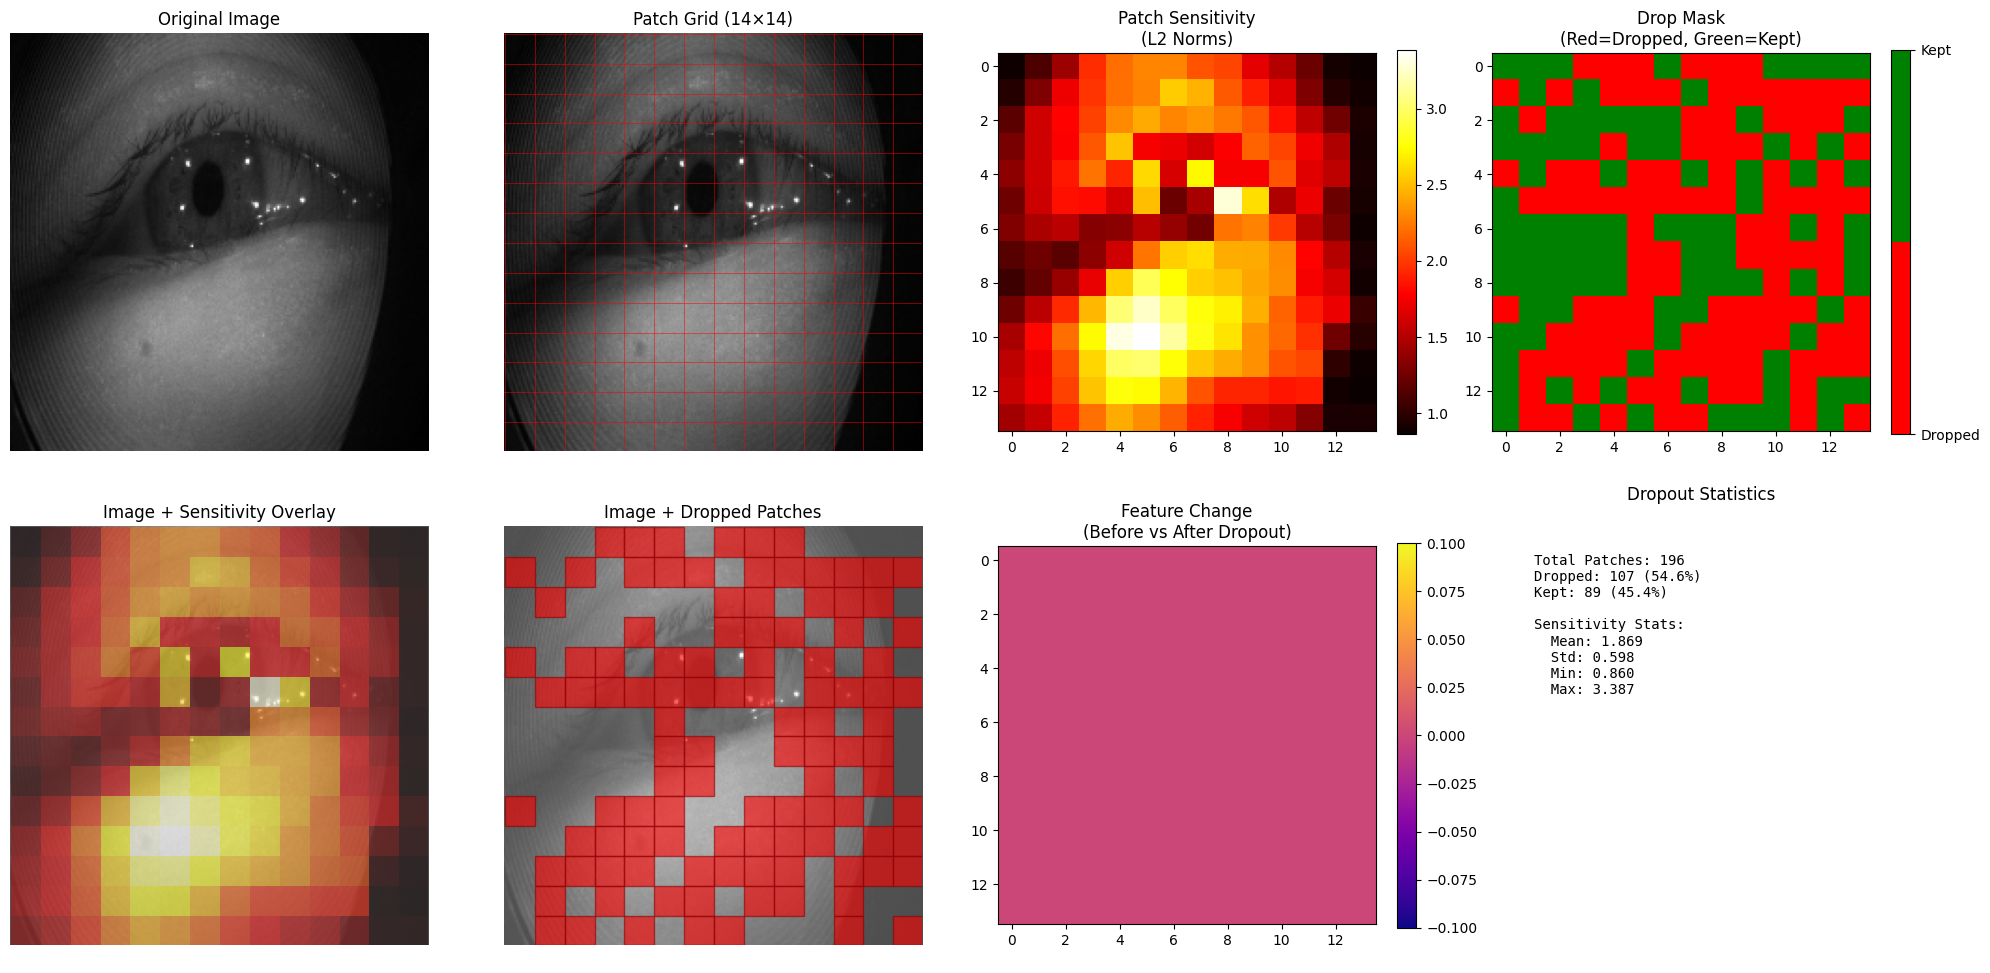


📊 Analyzing batch of 5 images for privacy effectiveness...
🔒 Analyzing Privacy Effectiveness of Adaptive Patch Dropout


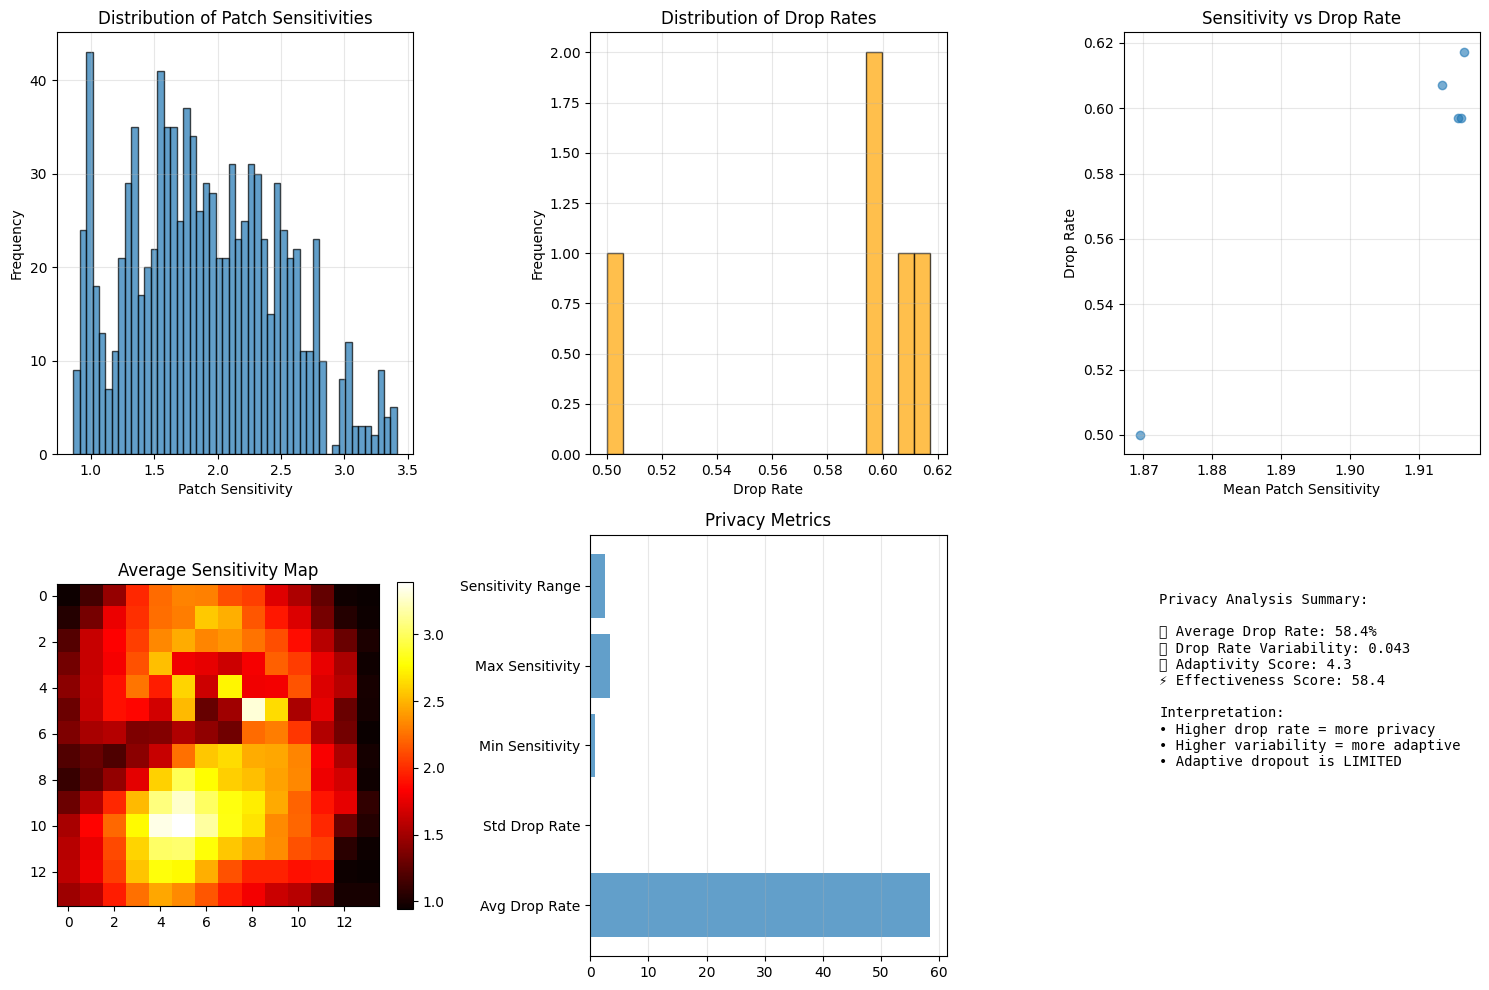


✅ Privacy Analysis Complete!
   Average Drop Rate: 58.4%
   Adaptivity Score: 4.25
   Effectiveness Score: 58.37


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

class AdaptivePatchDropVisualizer:
    """
    Specialized visualizer for Adaptive Privacy Patch Drop layer
    Shows which patches are dropped, sensitivity maps, and privacy analysis
    """
    
    def __init__(self, model):
        self.model = model
        self.patch_drop_layer = None
        self.patch_drop_extractor = None
        self.patch_extractor = None
        self.patch_embedding_extractor = None
        self._find_patch_drop_layer()
        
    def _find_patch_drop_layer(self):
        """Find the AdaptivePrivacyPatchDrop layer in the model"""
        for layer in self.model.layers:
            if 'adaptive' in layer.name.lower() and 'drop' in layer.name.lower():
                self.patch_drop_layer = layer
                print(f"Found Adaptive Patch Drop layer: {layer.name}")
                break
        
        if self.patch_drop_layer is None:
            print("❌ AdaptivePrivacyPatchDrop layer not found!")
            return
        
        # Build extractors for different stages
        self._build_extractors()
    
    def _build_extractors(self):
        """Build feature extractors for patch analysis"""
        try:
            # Find patch extraction layer
            patch_extract_layer = None
            patch_embedding_layer = None
            
            for layer in self.model.layers:
                if 'patch' in layer.name.lower() and 'extract' in layer.name.lower():
                    patch_extract_layer = layer
                elif 'patch' in layer.name.lower() and 'embedding' in layer.name.lower():
                    patch_embedding_layer = layer
            
            # Create extractors
            if patch_extract_layer:
                self.patch_extractor = tf.keras.Model(
                    inputs=self.model.input,
                    outputs=patch_extract_layer.output
                )
            
            if patch_embedding_layer:
                self.patch_embedding_extractor = tf.keras.Model(
                    inputs=self.model.input,
                    outputs=patch_embedding_layer.output
                )
            
            # Extractor for patch drop layer output
            self.patch_drop_extractor = tf.keras.Model(
                inputs=self.model.input,
                outputs=self.patch_drop_layer.output
            )
            
        except Exception as e:
            print(f"Error building extractors: {e}")
    
    def extract_patch_features(self, image):
        """Extract features at different stages of patch processing"""
        features = {}
        
        try:
            # Original patches
            if self.patch_extractor:
                features['raw_patches'] = self.patch_extractor.predict(image, verbose=0)
            
            # Embedded patches (before dropout)
            if self.patch_embedding_extractor:
                features['embedded_patches'] = self.patch_embedding_extractor.predict(image, verbose=0)
            
            # After patch dropout
            if self.patch_drop_extractor:
                features['dropped_patches'] = self.patch_drop_extractor.predict(image, verbose=0)
            
        except Exception as e:
            print(f"Error extracting features: {e}")
        
        return features
    
    def get_drop_mask_and_sensitivity(self, image):
        """
        Extract the actual drop mask and sensitivity scores from the layer
        This requires modifying the layer to expose intermediate values
        """
        # Create a modified version of the model that outputs intermediate values
        try:
            # We need to access the layer's internal state
            # This is a bit hacky but necessary to visualize the drop patterns
            
            # Get the layer's weights (sensitivity weights)
            if hasattr(self.patch_drop_layer, 'sensitivity_weights'):
                sensitivity_weights = self.patch_drop_layer.sensitivity_weights.numpy()
            else:
                sensitivity_weights = None
            
            # To get the actual mask, we need to run the model in training mode
            # and access the layer's last_mask attribute
            
            # Set training mode
            with tf.GradientTape() as tape:
                _ = self.model(image, training=True)
            
            # Get the last mask if available
            drop_mask = None
            if hasattr(self.patch_drop_layer, 'last_mask') and self.patch_drop_layer.last_mask is not None:
                drop_mask = self.patch_drop_layer.last_mask.numpy()
            
            return drop_mask, sensitivity_weights
            
        except Exception as e:
            print(f"Error getting drop mask: {e}")
            return None, None
    
    def visualize_patch_sensitivity(self, image, patch_size=16):
        """Visualize patch sensitivity and drop patterns"""
        
        # Extract features
        features = self.extract_patch_features(image)
        drop_mask, sensitivity_weights = self.get_drop_mask_and_sensitivity(image)
        
        if not features:
            print("No features extracted!")
            return
        
        # Calculate spatial dimensions
        img_size = 224
        patches_per_side = img_size // patch_size
        
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        
        # 1. Original Image
        img_display = image[0].squeeze()
        axes[0, 0].imshow(img_display, cmap='gray')
        axes[0, 0].set_title('Original Image')
        axes[0, 0].axis('off')
        
        # 2. Patch Grid
        axes[0, 1].imshow(img_display, cmap='gray')
        self._draw_patch_grid(axes[0, 1], img_size, patch_size)
        axes[0, 1].set_title(f'Patch Grid ({patches_per_side}×{patches_per_side})')
        axes[0, 1].axis('off')
        
        # 3. Patch Sensitivity Heatmap
        if 'embedded_patches' in features:
            embedded = features['embedded_patches'][0]  # Remove batch dim
            if embedded.shape[0] == 197:  # Remove class token if present
                embedded = embedded[1:]
            
            # Calculate patch norms as sensitivity proxy
            patch_norms = np.linalg.norm(embedded, axis=-1)
            sensitivity_map = patch_norms.reshape(patches_per_side, patches_per_side)
            
            im1 = axes[0, 2].imshow(sensitivity_map, cmap='hot', interpolation='nearest')
            axes[0, 2].set_title('Patch Sensitivity\n(L2 Norms)')
            plt.colorbar(im1, ax=axes[0, 2], fraction=0.046)
            
        # 4. Drop Mask Visualization
        if drop_mask is not None:
            # drop_mask shape: (batch, num_patches, 1)
            mask_2d = drop_mask[0, :, 0]  # Remove batch and channel dims
            if len(mask_2d) == 197:  # Remove class token if present
                mask_2d = mask_2d[1:]
            
            mask_spatial = mask_2d.reshape(patches_per_side, patches_per_side)
            
            # Create custom colormap: dropped=red, kept=green
            colors = ['red', 'green']
            cmap = ListedColormap(colors)
            
            im2 = axes[0, 3].imshow(mask_spatial, cmap=cmap, vmin=0, vmax=1)
            axes[0, 3].set_title('Drop Mask\n(Red=Dropped, Green=Kept)')
            cbar = plt.colorbar(im2, ax=axes[0, 3], fraction=0.046, ticks=[0, 1])
            cbar.ax.set_yticklabels(['Dropped', 'Kept'])
        else:
            axes[0, 3].text(0.5, 0.5, 'Drop mask\nnot available', 
                           ha='center', va='center', transform=axes[0, 3].transAxes)
            axes[0, 3].set_title('Drop Mask')
        
        # 5. Overlay: Original + Sensitivity
        axes[1, 0].imshow(img_display, cmap='gray', alpha=0.7)
        if 'embedded_patches' in features:
            # Overlay sensitivity as colored patches
            self._overlay_patch_values(axes[1, 0], sensitivity_map, patch_size, alpha=0.5, cmap='hot')
        axes[1, 0].set_title('Image + Sensitivity Overlay')
        axes[1, 0].axis('off')
        
        # 6. Overlay: Original + Drop Mask
        axes[1, 1].imshow(img_display, cmap='gray', alpha=0.7)
        if drop_mask is not None:
            # Overlay dropped patches in red
            self._overlay_dropped_patches(axes[1, 1], mask_spatial, patch_size)
        axes[1, 1].set_title('Image + Dropped Patches')
        axes[1, 1].axis('off')
        
        # 7. Feature Comparison: Before vs After Dropout
        if 'embedded_patches' in features and 'dropped_patches' in features:
            before = features['embedded_patches'][0]
            after = features['dropped_patches'][0]
            
            if before.shape[0] == 197:  # Remove class token
                before = before[1:]
            if after.shape[0] == 197:
                after = after[1:]
            
            # Calculate difference
            diff = np.linalg.norm(before - after, axis=-1)
            diff_map = diff.reshape(patches_per_side, patches_per_side)
            
            im3 = axes[1, 2].imshow(diff_map, cmap='plasma', interpolation='nearest')
            axes[1, 2].set_title('Feature Change\n(Before vs After Dropout)')
            plt.colorbar(im3, ax=axes[1, 2], fraction=0.046)
        
        # 8. Statistics
        axes[1, 3].axis('off')
        stats_text = self._calculate_dropout_statistics(features, drop_mask)
        axes[1, 3].text(0.1, 0.9, stats_text, transform=axes[1, 3].transAxes,
                       fontsize=10, verticalalignment='top', fontfamily='monospace')
        axes[1, 3].set_title('Dropout Statistics')
        
        plt.tight_layout()
        plt.show()
    
    def _draw_patch_grid(self, ax, img_size, patch_size):
        """Draw patch grid overlay"""
        for i in range(0, img_size, patch_size):
            ax.axhline(y=i, color='red', linewidth=0.5, alpha=0.7)
            ax.axvline(x=i, color='red', linewidth=0.5, alpha=0.7)
    
    def _overlay_patch_values(self, ax, values, patch_size, alpha=0.5, cmap='hot'):
        """Overlay patch values on image"""
        patches_per_side = values.shape[0]
        for i in range(patches_per_side):
            for j in range(patches_per_side):
                value = values[i, j]
                normalized_value = (value - values.min()) / (values.max() - values.min())
                
                rect = Rectangle((j * patch_size, i * patch_size), 
                               patch_size, patch_size,
                               facecolor=plt.cm.get_cmap(cmap)(normalized_value),
                               alpha=alpha)
                ax.add_patch(rect)
    
    def _overlay_dropped_patches(self, ax, mask, patch_size):
        """Overlay dropped patches in red"""
        patches_per_side = mask.shape[0]
        for i in range(patches_per_side):
            for j in range(patches_per_side):
                if mask[i, j] == 0:  # Dropped patch
                    rect = Rectangle((j * patch_size, i * patch_size), 
                                   patch_size, patch_size,
                                   facecolor='red', alpha=0.6, edgecolor='darkred')
                    ax.add_patch(rect)
    
    def _calculate_dropout_statistics(self, features, drop_mask):
        """Calculate and format dropout statistics"""
        stats = []
        
        if drop_mask is not None:
            mask = drop_mask[0, :, 0]  # Remove batch and channel dims
            if len(mask) == 197:  # Remove class token
                mask = mask[1:]
            
            total_patches = len(mask)
            dropped_patches = np.sum(mask == 0)
            kept_patches = np.sum(mask == 1)
            drop_rate = dropped_patches / total_patches * 100
            
            stats.append(f"Total Patches: {total_patches}")
            stats.append(f"Dropped: {dropped_patches} ({drop_rate:.1f}%)")
            stats.append(f"Kept: {kept_patches} ({100-drop_rate:.1f}%)")
            stats.append("")
        
        if 'embedded_patches' in features:
            embedded = features['embedded_patches'][0]
            if embedded.shape[0] == 197:
                embedded = embedded[1:]
            
            patch_norms = np.linalg.norm(embedded, axis=-1)
            stats.append(f"Sensitivity Stats:")
            stats.append(f"  Mean: {patch_norms.mean():.3f}")
            stats.append(f"  Std: {patch_norms.std():.3f}")
            stats.append(f"  Min: {patch_norms.min():.3f}")
            stats.append(f"  Max: {patch_norms.max():.3f}")
        
        return "\n".join(stats)
    
    def analyze_privacy_effectiveness(self, images_batch, labels=None):
        """
        Analyze how effective the patch dropout is for privacy
        """
        print("🔒 Analyzing Privacy Effectiveness of Adaptive Patch Dropout")
        print("=" * 60)
        
        all_sensitivities = []
        all_drop_rates = []
        
        for i, image in enumerate(images_batch):
            image_batch = np.expand_dims(image, axis=0)
            
            # Extract features
            features = self.extract_patch_features(image_batch)
            drop_mask, _ = self.get_drop_mask_and_sensitivity(image_batch)
            
            if 'embedded_patches' in features and drop_mask is not None:
                embedded = features['embedded_patches'][0]
                if embedded.shape[0] == 197:
                    embedded = embedded[1:]
                
                mask = drop_mask[0, :, 0]
                if len(mask) == 197:
                    mask = mask[1:]
                
                # Calculate sensitivity
                patch_sensitivity = np.linalg.norm(embedded, axis=-1)
                all_sensitivities.append(patch_sensitivity)
                
                # Calculate drop rate
                drop_rate = np.sum(mask == 0) / len(mask)
                all_drop_rates.append(drop_rate)
        
        if all_sensitivities:
            # Analyze patterns
            plt.figure(figsize=(15, 10))
            
            # 1. Sensitivity distribution
            plt.subplot(2, 3, 1)
            all_sens_flat = np.concatenate(all_sensitivities)
            plt.hist(all_sens_flat, bins=50, alpha=0.7, edgecolor='black')
            plt.xlabel('Patch Sensitivity')
            plt.ylabel('Frequency')
            plt.title('Distribution of Patch Sensitivities')
            plt.grid(True, alpha=0.3)
            
            # 2. Drop rate distribution
            plt.subplot(2, 3, 2)
            plt.hist(all_drop_rates, bins=20, alpha=0.7, edgecolor='black', color='orange')
            plt.xlabel('Drop Rate')
            plt.ylabel('Frequency')
            plt.title('Distribution of Drop Rates')
            plt.grid(True, alpha=0.3)
            
            # 3. Sensitivity vs Drop Rate correlation
            plt.subplot(2, 3, 3)
            mean_sensitivities = [np.mean(sens) for sens in all_sensitivities]
            plt.scatter(mean_sensitivities, all_drop_rates, alpha=0.6)
            plt.xlabel('Mean Patch Sensitivity')
            plt.ylabel('Drop Rate')
            plt.title('Sensitivity vs Drop Rate')
            plt.grid(True, alpha=0.3)
            
            # 4. Spatial pattern analysis
            plt.subplot(2, 3, 4)
            if len(all_sensitivities) > 0:
                # Average sensitivity across all images
                avg_sensitivity = np.mean(all_sensitivities, axis=0)
                patches_per_side = int(np.sqrt(len(avg_sensitivity)))
                sensitivity_map = avg_sensitivity.reshape(patches_per_side, patches_per_side)
                
                im = plt.imshow(sensitivity_map, cmap='hot', interpolation='nearest')
                plt.title('Average Sensitivity Map')
                plt.colorbar(im, fraction=0.046)
            
            # 5. Privacy metrics
            plt.subplot(2, 3, 5)
            privacy_metrics = {
                'Avg Drop Rate': f"{np.mean(all_drop_rates):.2%}",
                'Std Drop Rate': f"{np.std(all_drop_rates):.3f}",
                'Min Sensitivity': f"{np.min(all_sens_flat):.3f}",
                'Max Sensitivity': f"{np.max(all_sens_flat):.3f}",
                'Sensitivity Range': f"{np.max(all_sens_flat) - np.min(all_sens_flat):.3f}"
            }
            
            y_pos = np.arange(len(privacy_metrics))
            plt.barh(y_pos, [float(v.strip('%')) if '%' in v else float(v) 
                           for v in privacy_metrics.values()], alpha=0.7)
            plt.yticks(y_pos, privacy_metrics.keys())
            plt.title('Privacy Metrics')
            plt.grid(True, alpha=0.3, axis='x')
            
            # 6. Effectiveness summary
            plt.subplot(2, 3, 6)
            plt.axis('off')
            
            effectiveness_score = np.mean(all_drop_rates) * 100
            adaptivity_score = np.std(all_drop_rates) * 100
            
            summary_text = f"""
Privacy Analysis Summary:

🎯 Average Drop Rate: {np.mean(all_drop_rates):.1%}
📊 Drop Rate Variability: {np.std(all_drop_rates):.3f}
🔄 Adaptivity Score: {adaptivity_score:.1f}
⚡ Effectiveness Score: {effectiveness_score:.1f}

Interpretation:
• Higher drop rate = more privacy
• Higher variability = more adaptive
• Adaptive dropout is {'WORKING' if adaptivity_score > 5 else 'LIMITED'}
            """
            
            plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes,
                    fontsize=10, verticalalignment='top', fontfamily='monospace')
            
            plt.tight_layout()
            plt.show()
            
            return {
                'mean_drop_rate': np.mean(all_drop_rates),
                'std_drop_rate': np.std(all_drop_rates),
                'mean_sensitivity': np.mean(all_sens_flat),
                'adaptivity_score': adaptivity_score,
                'effectiveness_score': effectiveness_score
            }
        
        return None

# Enhanced usage function
def visualize_adaptive_patch_dropout_complete(model, image_path, num_samples=5):
    """
    Complete visualization of Adaptive Patch Dropout layer
    """
    
    # Load and preprocess image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(image, (224, 224))
    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)
    img = img.astype(np.float32) / 255.0
    
    # Create visualizer
    visualizer = AdaptivePatchDropVisualizer(model)
    
    if visualizer.patch_drop_layer is None:
        print("❌ No Adaptive Patch Drop layer found in the model!")
        return
    
    print("🎯 Visualizing Adaptive Privacy Patch Dropout Layer")
    print("=" * 60)
    
    # 1. Visualize single image
    print("\n📸 Analyzing single image patch sensitivity and dropout...")
    visualizer.visualize_patch_sensitivity(img)
    
    # 2. Batch analysis (if you have multiple images)
    # For demo, we'll create variations of the same image
    print(f"\n📊 Analyzing batch of {num_samples} images for privacy effectiveness...")
    
    batch_images = []
    for i in range(num_samples):
        # Create slight variations (noise, brightness) for analysis
        varied_img = img.copy()
        if i > 0:
            noise = np.random.normal(0, 0.02, varied_img.shape)
            varied_img = np.clip(varied_img + noise, 0, 1)
        batch_images.append(varied_img[0])  # Remove batch dimension
    
    # Analyze privacy effectiveness
    privacy_analysis = visualizer.analyze_privacy_effectiveness(batch_images)
    
    if privacy_analysis:
        print(f"\n✅ Privacy Analysis Complete!")
        print(f"   Average Drop Rate: {privacy_analysis['mean_drop_rate']:.1%}")
        print(f"   Adaptivity Score: {privacy_analysis['adaptivity_score']:.2f}")
        print(f"   Effectiveness Score: {privacy_analysis['effectiveness_score']:.2f}")
    
    return visualizer

# Example usage
if __name__ == "__main__":
    # Your model and image path
    image_path = './openEDS/openEDS/S_15/100.png'
    
    # Run complete adaptive patch dropout visualization
    visualizer = visualize_adaptive_patch_dropout_complete(model, image_path)

Original image shape: (400, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted mask shape: (224, 224)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

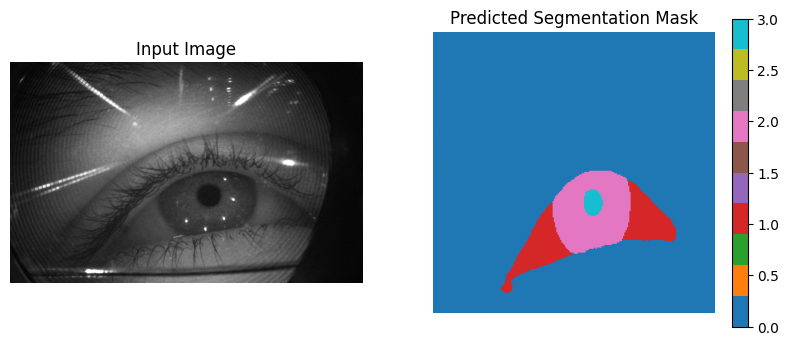

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

image_path = './openEDS/openEDS/S_10/10.png'

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
print("Original image shape:", image.shape)
img_input = np.expand_dims(image, axis=(0, -1))  # e.g., (1, 240, 320, 1)

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(image, (224, 224))
img = np.expand_dims(img, axis=-1)
img = np.expand_dims(img, axis=0)
# img = img.astype(np.float32) / 255.0  # Normalize

# Predict
predicted_mask = model.predict(img)
predicted_mask = np.argmax(predicted_mask, axis=-1)[0]

# custom_objects = {
#             'GaussianBlur': GaussianBlur,
#             'GaussianNoiseLayer': GaussianNoiseLayer,
#             'WeightNoiseLayer': WeightNoiseLayer,
#             'FeatureEncryptionLayer': FeatureEncryptionLayer,
#             'LightInvarianceLayer': LightInvarianceLayer,
#             'dice_coefficient_multiclass': dice_coefficient_multiclass,
#             'iou_metric_multiclass': iou_metric_multiclass,
#         }
# model = tf.keras.models.load_model("privacy_preserving_unet_medium_light_invariance.h5", custom_objects=custom_objects)

print("Predicted mask shape:", predicted_mask.shape)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask, cmap='tab10', vmin=0, vmax=3)
plt.title("Predicted Segmentation Mask")
plt.colorbar()
plt.axis('off')

Original image shape: (400, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predicted mask shape: (224, 224)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

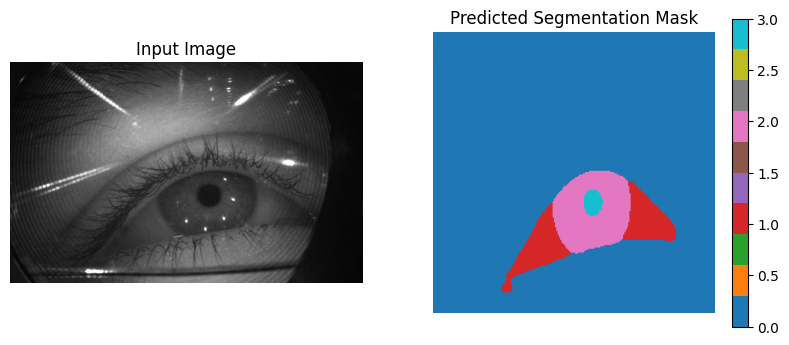

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

image_path = './openEDS/openEDS/S_10/10.png'

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
print("Original image shape:", image.shape)
img_input = np.expand_dims(image, axis=(0, -1))  # e.g., (1, 240, 320, 1)

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(image, (224, 224))
img = np.expand_dims(img, axis=-1)
img = np.expand_dims(img, axis=0)

model = tf.keras.models.load_model(
    "./best_enhanced_vit_eye_model_batch_current.h5",
    custom_objects={
        "PatchExtract": PatchExtract,
        "PatchEmbedding": PatchEmbedding,
        "PrivacyAwareFeatureExtractor": PrivacyAwareFeatureExtractor,
        "TransformerBlock": TransformerBlock,
        "DifferentialPrivacyLayer": DifferentialPrivacyLayer,
        "AdaptivePrivacyPatchDrop": AdaptivePrivacyPatchDrop,
        "GetItem": GetItem,
        "UpsampleBlock": UpsampleBlock,
    },
    compile=False
)

predicted_mask = model.predict(img)
predicted_mask = np.argmax(predicted_mask, axis=-1)[0]

# custom_objects = {
#             'GaussianBlur': GaussianBlur,
#             'GaussianNoiseLayer': GaussianNoiseLayer,
#             'WeightNoiseLayer': WeightNoiseLayer,
#             'FeatureEncryptionLayer': FeatureEncryptionLayer,
#             'LightInvarianceLayer': LightInvarianceLayer,
#             'dice_coefficient_multiclass': dice_coefficient_multiclass,
#             'iou_metric_multiclass': iou_metric_multiclass,
#         }
# model = tf.keras.models.load_model("privacy_preserving_unet_medium_light_invariance.h5", custom_objects=custom_objects)

print("Predicted mask shape:", predicted_mask.shape)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask, cmap='tab10', vmin=0, vmax=3)
plt.title("Predicted Segmentation Mask")
plt.colorbar()
plt.axis('off')

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

"""
Model Inference Attack Testing Suite for Privacy-Aware Eye Segmentation
Tests various privacy attacks including membership inference and attribute inference
"""

class MembershipInferenceAttack:
    """
    Membership Inference Attack (MIA)
    Goal: Determine if a specific sample was in the training set
    
    This is the most common privacy attack - if successful, it means the model
    memorized training data, which could leak sensitive information.
    """
    
    def __init__(self, shadow_models=3):
        self.shadow_models = shadow_models
        self.attack_model = None
        
    def build_attack_model(self, input_dim):
        """Build neural network to perform membership inference"""
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(1, activation='sigmoid')  # Binary: member or not
        ])
        
        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        return model
    
    def extract_attack_features(self, model, data, labels):
        """
        Extract features for attack model
        Features include: prediction confidence, loss, entropy
        """
        predictions = model.predict(data, verbose=0)
        
        # Calculate per-sample loss
        losses = []
        for i in range(len(data)):
            sample_pred = predictions[i:i+1]
            sample_label = labels[i:i+1]
            loss = tf.keras.losses.sparse_categorical_crossentropy(
                sample_label, sample_pred
            )
            losses.append(np.mean(loss.numpy()))
        
        losses = np.array(losses)
        
        # Max confidence (highest probability)
        max_confidence = np.max(predictions.reshape(len(predictions), -1), axis=-1)
        
        # Prediction entropy
        pred_flat = predictions.reshape(len(predictions), -1)
        pred_flat = np.clip(pred_flat, 1e-10, 1.0)  # Avoid log(0)
        entropy = -np.sum(pred_flat * np.log(pred_flat), axis=-1)
        
        # Correct prediction indicator
        pred_classes = np.argmax(predictions, axis=-1)
        correct = (pred_classes == labels.squeeze()).astype(float).mean(axis=(1,2))
        
        # Combine features
        features = np.stack([
            losses,
            max_confidence,
            entropy,
            correct
        ], axis=1)
        
        return features
    
    def train_attack(self, target_model, train_data, train_labels, test_data, test_labels):
        """
        Train the membership inference attack
        
        Args:
            target_model: The model to attack
            train_data: Data that WAS in training
            train_labels: Labels for training data
            test_data: Data that WAS NOT in training
            test_labels: Labels for test data
        """
        print("Extracting features for attack model...")
        
        # Extract features from members (training data)
        train_features = self.extract_attack_features(target_model, train_data, train_labels)
        train_membership = np.ones(len(train_features))  # Label: 1 = member
        
        # Extract features from non-members (test data)
        test_features = self.extract_attack_features(target_model, test_data, test_labels)
        test_membership = np.zeros(len(test_features))  # Label: 0 = non-member
        
        # Combine and shuffle
        X = np.vstack([train_features, test_features])
        y = np.concatenate([train_membership, test_membership])
        
        # Split for training attack model
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        
        print("Training attack model...")
        input_dim = X_train.shape[1]
        self.attack_model = self.build_attack_model(input_dim)
        
        history = self.attack_model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=50,
            batch_size=32,
            verbose=0
        )
        
        # Evaluate attack
        y_pred_proba = self.attack_model.predict(X_test, verbose=0)
        y_pred = (y_pred_proba > 0.5).astype(int)
        
        accuracy = accuracy_score(y_test, y_pred)
        
        # Calculate AUC
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        
        results = {
            'accuracy': accuracy,
            'auc': roc_auc,
            'fpr': fpr,
            'tpr': tpr,
            'history': history.history
        }
        
        return results
    
    def plot_results(self, results):
        """Visualize attack results"""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # ROC Curve
        axes[0].plot(results['fpr'], results['tpr'], 
                    label=f'Attack (AUC = {results["auc"]:.3f})')
        axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
        axes[0].set_xlabel('False Positive Rate')
        axes[0].set_ylabel('True Positive Rate')
        axes[0].set_title('Membership Inference Attack - ROC Curve')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Training history
        axes[1].plot(results['history']['accuracy'], label='Train Accuracy')
        axes[1].plot(results['history']['val_accuracy'], label='Val Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Attack Model Training')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('membership_inference_attack.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print interpretation
        print("\n" + "="*60)
        print("MEMBERSHIP INFERENCE ATTACK RESULTS")
        print("="*60)
        print(f"Attack Accuracy: {results['accuracy']:.3f}")
        print(f"AUC Score: {results['auc']:.3f}")
        print("\nInterpretation:")
        if results['auc'] < 0.55:
            print("✓ STRONG PRIVACY: Attack barely better than random guessing")
        elif results['auc'] < 0.65:
            print("⚠ MODERATE PRIVACY: Some privacy leakage detected")
        elif results['auc'] < 0.80:
            print("⚠ WEAK PRIVACY: Significant privacy leakage")
        else:
            print("✗ POOR PRIVACY: Severe privacy leakage - model memorizes training data")
        print("="*60)


class AttributeInferenceAttack:
    """
    Attribute Inference Attack
    Goal: Infer sensitive attributes not directly used in training
    
    For eye images, this could include inferring identity, age, ethnicity, etc.
    """
    
    def __init__(self):
        self.attack_model = None
    
    def build_attack_model(self, input_shape, num_classes):
        """Build model to infer attributes from representations"""
        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=input_shape),
            tf.keras.layers.GlobalAveragePooling2D() if len(input_shape) > 1 else tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(256, activation='relu'),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(num_classes, activation='softmax')
        ])
        
        model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return model
    
    def extract_intermediate_outputs(self, model, data, layer_name=None):
        """Extract intermediate layer outputs as attack features"""
        if layer_name is None:
            # Use the last transformer block output
            for layer in reversed(model.layers):
                if 'transformer' in layer.name.lower():
                    layer_name = layer.name
                    break
        
        if layer_name is None:
            raise ValueError("Could not find suitable intermediate layer")
        
        intermediate_model = tf.keras.Model(
            inputs=model.input,
            outputs=model.get_layer(layer_name).output
        )
        
        features = intermediate_model.predict(data, verbose=0)
        return features
    
    def train_attack(self, target_model, data, sensitive_labels, layer_name=None):
        """
        Train attribute inference attack
        
        Args:
            target_model: Model to attack
            data: Input images
            sensitive_labels: Sensitive attributes to infer (e.g., person ID)
        """
        print("Extracting intermediate representations...")
        features = self.extract_intermediate_outputs(target_model, data, layer_name)
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            features, sensitive_labels, test_size=0.3, random_state=42
        )
        
        print("Training attribute inference attack...")
        num_classes = len(np.unique(sensitive_labels))
        self.attack_model = self.build_attack_model(features.shape[1:], num_classes)
        
        history = self.attack_model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=30,
            batch_size=32,
            verbose=0
        )
        
        # Evaluate
        y_pred = self.attack_model.predict(X_test, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        accuracy = accuracy_score(y_test, y_pred_classes)
        
        # Random baseline
        random_accuracy = 1.0 / num_classes
        
        results = {
            'accuracy': accuracy,
            'random_baseline': random_accuracy,
            'num_classes': num_classes,
            'history': history.history
        }
        
        return results
    
    def plot_results(self, results):
        """Visualize attack results"""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Accuracy comparison
        categories = ['Random\nGuessing', 'Attack\nModel']
        accuracies = [results['random_baseline'], results['accuracy']]
        colors = ['gray', 'red' if results['accuracy'] > results['random_baseline'] * 1.5 else 'orange']
        
        axes[0].bar(categories, accuracies, color=colors, alpha=0.7)
        axes[0].set_ylabel('Accuracy')
        axes[0].set_title('Attribute Inference Attack Performance')
        axes[0].set_ylim([0, 1])
        axes[0].grid(True, alpha=0.3, axis='y')
        
        # Training history
        axes[1].plot(results['history']['accuracy'], label='Train')
        axes[1].plot(results['history']['val_accuracy'], label='Validation')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Attack Model Training')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('attribute_inference_attack.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n" + "="*60)
        print("ATTRIBUTE INFERENCE ATTACK RESULTS")
        print("="*60)
        print(f"Number of classes: {results['num_classes']}")
        print(f"Random baseline: {results['random_baseline']:.3f}")
        print(f"Attack accuracy: {results['accuracy']:.3f}")
        print(f"Improvement over random: {results['accuracy']/results['random_baseline']:.2f}x")
        print("\nInterpretation:")
        if results['accuracy'] < results['random_baseline'] * 1.2:
            print("✓ STRONG PRIVACY: Cannot infer sensitive attributes")
        elif results['accuracy'] < results['random_baseline'] * 2:
            print("⚠ MODERATE PRIVACY: Some attribute leakage")
        else:
            print("✗ POOR PRIVACY: Sensitive attributes easily inferred")
        print("="*60)


class ModelInversionAttack:
    """
    Model Inversion Attack
    Goal: Reconstruct training samples from model parameters
    
    Uses gradient-based optimization to find inputs that maximize
    specific class activations.
    """
    
    def __init__(self, num_iterations=1000, learning_rate=0.1):
        self.num_iterations = num_iterations
        self.learning_rate = learning_rate
    
    def invert_model(self, model, target_class, input_shape):
        """
        Attempt to reconstruct what the model learned about a specific class
        
        Args:
            model: Target model
            target_class: Class to reconstruct
            input_shape: Shape of input images
        """
        print(f"Attempting to reconstruct class {target_class}...")
        
        # Start with random noise
        reconstructed = tf.Variable(
            tf.random.normal([1] + list(input_shape)), dtype=tf.float32
        )
        
        optimizer = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        
        losses = []
        
        for i in range(self.num_iterations):
            with tf.GradientTape() as tape:
                tape.watch(reconstructed)
                
                # Forward pass
                predictions = model(reconstructed, training=False)
                
                # Target: maximize probability of target class
                target_prob = predictions[0, :, :, target_class]
                loss = -tf.reduce_mean(target_prob)
                
                # Add regularization to keep image realistic
                reg_loss = 0.01 * tf.reduce_mean(tf.square(reconstructed))
                total_loss = loss + reg_loss
            
            # Compute gradients
            grads = tape.gradient(total_loss, reconstructed)
            
            # Update reconstructed image
            optimizer.apply_gradients([(grads, reconstructed)])
            
            # Clip to valid range
            reconstructed.assign(tf.clip_by_value(reconstructed, 0.0, 1.0))
            
            losses.append(total_loss.numpy())
            
            if i % 100 == 0:
                print(f"Iteration {i}/{self.num_iterations}, Loss: {total_loss.numpy():.4f}")
        
        return reconstructed.numpy()[0], losses
    
    def visualize_reconstruction(self, original_samples, reconstructed_samples, class_names):
        """Compare original samples with reconstructed ones"""
        num_classes = len(reconstructed_samples)
        
        fig, axes = plt.subplots(2, num_classes, figsize=(3*num_classes, 6))
        
        for i in range(num_classes):
            # Original sample
            axes[0, i].imshow(original_samples[i].squeeze(), cmap='gray')
            axes[0, i].set_title(f'Original\n{class_names[i]}')
            axes[0, i].axis('off')
            
            # Reconstructed
            axes[1, i].imshow(reconstructed_samples[i].squeeze(), cmap='gray')
            axes[1, i].set_title(f'Reconstructed\n{class_names[i]}')
            axes[1, i].axis('off')
        
        plt.tight_layout()
        plt.savefig('model_inversion_attack.png', dpi=300, bbox_inches='tight')
        plt.show()


def comprehensive_privacy_test(
    model_original, 
    model_with_privacy,
    train_data, 
    train_labels,
    test_data,
    test_labels,
    sensitive_attributes=None
):
    """
    Run comprehensive privacy attack suite
    
    Args:
        model_original: Model without privacy layers
        model_with_privacy: Model with privacy layers
        train_data: Training images
        train_labels: Training segmentation labels
        test_data: Test images  
        test_labels: Test segmentation labels
        sensitive_attributes: Optional sensitive labels (e.g., person ID)
    """
    
    print("\n" + "="*80)
    print("COMPREHENSIVE PRIVACY ATTACK TESTING")
    print("="*80)
    
    # Test 1: Membership Inference Attack
    print("\n[1/3] Testing Membership Inference Attack...")
    print("-" * 80)
    
    mia = MembershipInferenceAttack()
    
    print("\nAttacking ORIGINAL model (no privacy)...")
    results_original = mia.train_attack(
        model_original, 
        train_data[:500], train_labels[:500],
        test_data[:500], test_labels[:500]
    )
    
    print("\nAttacking model WITH PRIVACY layers...")
    results_privacy = mia.train_attack(
        model_with_privacy,
        train_data[:500], train_labels[:500], 
        test_data[:500], test_labels[:500]
    )
    
    # Compare results
    print("\n" + "="*80)
    print("MEMBERSHIP INFERENCE COMPARISON")
    print("="*80)
    print(f"Original Model AUC: {results_original['auc']:.3f}")
    print(f"Privacy Model AUC:  {results_privacy['auc']:.3f}")
    print(f"Privacy Improvement: {((results_original['auc'] - results_privacy['auc']) / results_original['auc'] * 100):.1f}%")
    print("="*80)
    
    mia.plot_results(results_original)
    
    # Test 2: Attribute Inference Attack (if sensitive attributes provided)
    if sensitive_attributes is not None:
        print("\n[2/3] Testing Attribute Inference Attack...")
        print("-" * 80)
        
        aia = AttributeInferenceAttack()
        
        print("\nAttacking ORIGINAL model...")
        attr_results_original = aia.train_attack(
            model_original,
            train_data[:500],
            sensitive_attributes[:500]
        )
        
        print("\nAttacking model WITH PRIVACY layers...")
        attr_results_privacy = aia.train_attack(
            model_with_privacy,
            train_data[:500],
            sensitive_attributes[:500]
        )
        
        print("\n" + "="*80)
        print("ATTRIBUTE INFERENCE COMPARISON")
        print("="*80)
        print(f"Original Model Accuracy: {attr_results_original['accuracy']:.3f}")
        print(f"Privacy Model Accuracy:  {attr_results_privacy['accuracy']:.3f}")
        print(f"Privacy Improvement: {((attr_results_original['accuracy'] - attr_results_privacy['accuracy']) / attr_results_original['accuracy'] * 100):.1f}%")
        print("="*80)
        
        aia.plot_results(attr_results_privacy)
    
    print("\n[3/3] Privacy testing complete!")
    print("="*80)
    
    return {
        'membership_inference': {
            'original': results_original,
            'privacy': results_privacy
        },
        'attribute_inference': {
            'original': attr_results_original if sensitive_attributes else None,
            'privacy': attr_results_privacy if sensitive_attributes else None
        }
    }


# Example usage function
def example_usage():
    """
    Example of how to use the privacy attack suite
    """
    print("Example Usage of Privacy Attack Suite")
    print("="*60)
    
    # Assuming you have:
    # - model_original: Your model without privacy layers
    # - model_with_privacy: Your model with privacy layers  
    # - X_train, y_train: Training data and labels
    # - X_test, y_test: Test data and labels
    # - person_ids: Sensitive attribute (e.g., which person each sample belongs to)
    
    # Run comprehensive test
    results = comprehensive_privacy_test(
    model_original=model_original,
    model_with_privacy=model_with_privacy,
    train_data=X_train[:1000],
    train_labels=y_train[:1000],
    test_data=X_test[:1000],
    test_labels=y_test[:1000],
    sensitive_attributes=person_ids[:1000]  # Optional
)
    
    return results


if __name__ == "__main__":
    print("Privacy Attack Testing Suite for Eye Segmentation Model")
    print("="*60)
    print("\nThis suite implements three types of privacy attacks:")
    print("1. Membership Inference Attack - Can we tell if data was used in training?")
    print("2. Attribute Inference Attack - Can we infer sensitive attributes?")
    print("3. Model Inversion Attack - Can we reconstruct training data?")
    print("\nLower attack success = Better privacy protection")
    print("="*60)